In [55]:
from OceanDataStore import OceanDataCatalog
from nemo_cookbook import NEMODataTree
import gsw
import xarray as xr
import os 
import dask 
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import pandas as pd

from helper_function import solve_vertical_modes
from scipy.linalg import eigh

In [2]:
# dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
#                  'local_directory': f"{os.getcwd()}/dask_tmp"
#                  })

# # Create Local Cluster:
# cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
# client = Client(cluster)
# client

In [3]:
catalog = OceanDataCatalog(catalog_name="noc-stac") 

ds_domain = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg", consolidated=True, chunks={})

ds_gridT = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})
ds_gridU = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/U1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})
ds_gridV = xr.open_zarr("https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/V1m", consolidated=True, chunks={"time_counter": 4, "k": 25, "j": 100, "i": 120})

ds_gridT_y = ds_gridT.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "deptht": 25, "y": 100, "x": 120})
ds_gridT_y["sigma0"] = gsw.density.sigma0(CT=ds_gridT_y["thetao_con"], SA=ds_gridT_y["so_abs"])
ds_gridT_y["sigma0"].name = "sigma0"
ds_gridU_y = ds_gridU.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "depthu": 25, "y": 100, "x": 120})
ds_gridV_y = ds_gridV.resample(time_counter="1YE").mean().chunk({"time_counter": 5, "depthv": 25, "y": 100, "x": 120})

datasets_y = {"parent": {"domain": ds_domain, "gridT": ds_gridT_y, "gridU": ds_gridU_y, "gridV": ds_gridV_y}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo_y = NEMODataTree.from_datasets(datasets=datasets_y, iperio=True, nftype="F", read_mask=True)

# catalog = OceanDataCatalog(catalog_name="noc-stac")

# catalog.search(collection="noc-npd-era5")
# # catalog.available_items

# ds_domain = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/domain/domain_cfg')
# ds_gridT = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/T1m')
# ds_gridU = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/U1m')
# ds_gridV = catalog.open_dataset('noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/V1m')

# # ds_gridT['sigma0'] = gsw.density.sigma0(CT=ds_gridT['thetao_con'], SA=ds_gridT['so_abs'])
# # ds_gridT['sigma0'].name = 'sigma0'

# datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT, "gridU": ds_gridU, "gridV": ds_gridV}}
# nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

In [4]:
# atlmask_T = (ds_domain["atlmsk"].rename({"x": "i", "y": "j"}).astype(bool))
# atlmask_T = atlmask_T.assign_coords(i=nemo_y["gridT/sigma0"].i,j=nemo_y["gridT/sigma0"].j)

# sigma0_mean = (nemo_y["gridT/sigma0"].where(atlmask_T).mean( dim=["time_counter", "j", "i"], skipna=True))

# N2_mean = (g / rho_0 * sigma0_mean.differentiate("deptht")) # originally ran with negative value
# N2_mean.name = "N2" # rename variable calculated as N2 instead of signam0
# print("Mean N2 calculated")

# with ProgressBar():
#     N2_mean.to_netcdf("N2_mean.nc", compute=True)

In [5]:
g = 9.8 # gravity 
rho_0 = 1026 # reference sea water denisty

###
# overturnign streamfunction #
###
atlmask = ds_domain['atlmsk'].rename({"x":"i", "y":"j"}).astype(bool) # assign to V-grid
atlmask['i'] = atlmask['i'] + 1
atlmask['j'] = atlmask['j'] + 1.5
Psi = nemo_y['gridV/vo'].integral(dims=["i", "k"], cum_dims=["k"], dir="+1", mask=atlmask)
print('Overturning streamfunciton calculated')

###
# geostorphic compoennt 
###
f_V = ds_domain["ff_f"].rename({"x": "i", "y": "j"}) # corilis parameter on V-grid
f_V = f_V.assign_coords(i=nemo_y["gridV/vo"].i, j=nemo_y["gridV/vo"].j)

dsigma_dx = nemo_y["gridT/sigma0"].derivative(dim="i").interp_to(to="V")
dv_dz = -g * dsigma_dx / (rho_0 * f_V)
v_g = dv_dz.integral(dims=["k"], cum_dims=["k"], dir="+1")
v_g_rel = v_g - v_g.isel(k=-1) # zero velocity at depth 

Psi_geostrophic = ((v_g_rel * nemo_y["gridV/e1v"]).sum(dim="i"))
Psi_geostrophic = Psi_geostrophic.where(atlmask.any(dim="i"))
print('Geostrophic streamfunciton calculated')

###
# ekamn compoennt 
###
f_U = ds_domain["ff_f"].rename({"x": "i", "y": "j"})
f_U = f_U.assign_coords(i=nemo_y["gridU/tauuo"].i, j=nemo_y["gridU/tauuo"].j)
M_e = nemo_y["gridU/tauuo"] / (rho_0 * f_U)
Psi_ek = (M_e * nemo_y["gridU/e1u"]).interp_to(to="V").sum(dim="i")
print('Ekman streamfunciton calculated')

###
# residaul 
###
Psi_residual = Psi - Psi_geostrophic - Psi_ek
print('Residual streamfunciton calculated')

Overturning streamfunciton calculated
Geostrophic streamfunciton calculated
Ekman streamfunciton calculated
Residual streamfunciton calculated


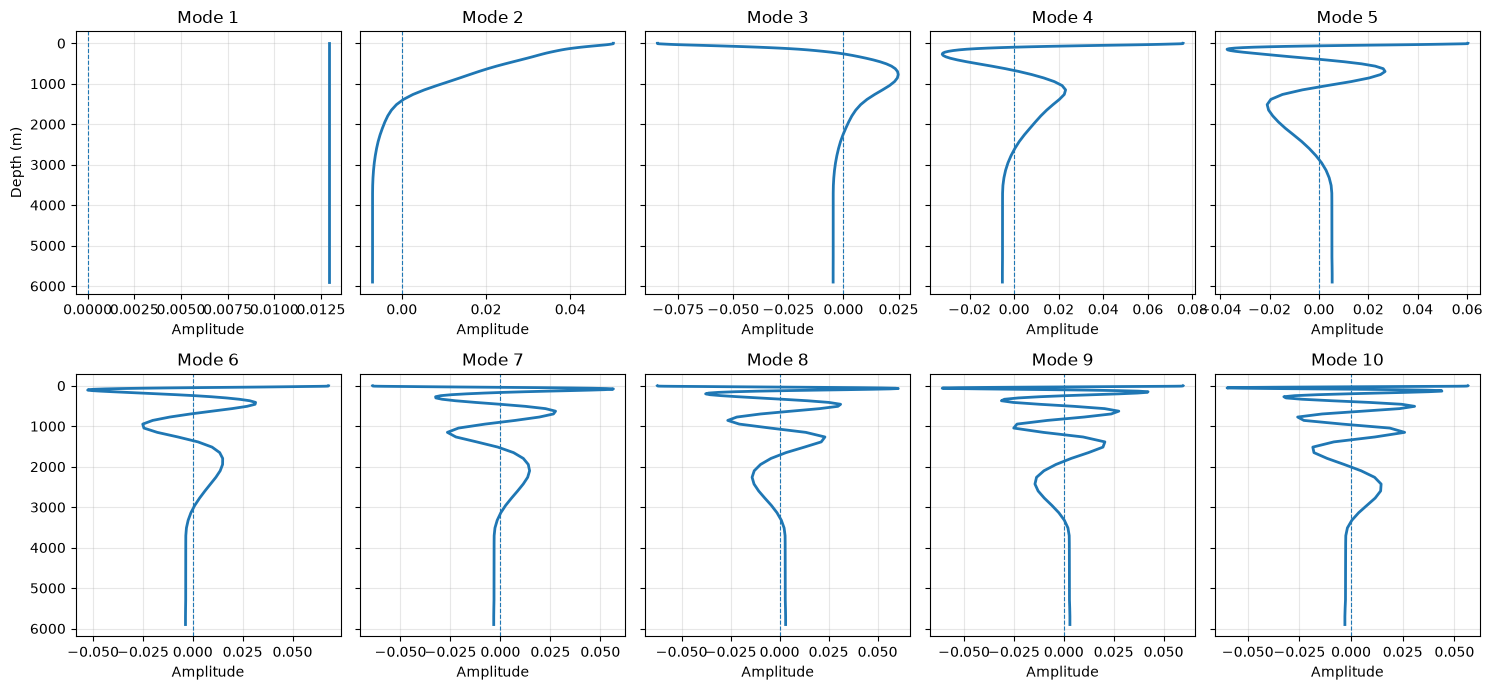

In [31]:
# calculating normal modes 
z = Psi.depthv.values # depth points 
N2 = xr.open_dataset("N2_mean.nc").sigma0.values
N2 = -N2 # wronmg sign convention when saving the data

# identify and clean problematic poitns 
N2_clean = N2.copy()
bad = ~np.isfinite(N2_clean) | (N2_clean <= 0)
N2_min = 1e-9
N2_clean[bad] = N2_min
# print("Number of modified points:", bad.sum())
# print("Indices:", np.where(bad)[0])
# print("Original values:", N2_clean[bad])

# calculate normal modes
eigenvals, eigenvecs, B = solve_vertical_modes(N2_clean, z)
eigenvecs_xr = xr.DataArray(eigenvecs, dims=("k", "mode"),
    coords={"k": Psi.depthv, "mode": np.arange(1, eigenvecs.shape[1] + 1)}, name="normal_modes")
B_xr = xr.DataArray(B, dims=("k", "k2"),
    coords={"k": Psi.depthv, "k2": Psi.depthv}, name="weight_matrix")

# plotting 
fig, axes = plt.subplots(2, 5, figsize=(15, 7), sharey=True)
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.plot(eigenvecs[:, i], z, linewidth=2)
    ax.axvline(0, linestyle='--', linewidth=0.8)

    ax.set_title(f'Mode {i+1}')
    ax.set_xlabel('Amplitude')
    ax.grid(True, alpha=0.3)

# Depth only needs to be labelled on the first subplot
axes[0].set_ylabel('Depth (m)')

# If depth increases downward:
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

In [50]:
j_idx = 230
Psi_j = Psi.isel(j=j_idx)
Psi_j
Psi_j_clean = xr.DataArray(Psi_j.data, dims=("time_counter", "k"),
    coords={"time_counter": Psi_j.time_counter, "depthv": ("k", Psi_j.depthv.values)}, name="Psi")

weighted_Psi = xr.dot(B_xr, Psi_j_clean, dims="k2")
a = xr.dot(eigenvecs_xr, weighted_Psi, dims="k")
print(a)

<xarray.DataArray 'normal_modes' (mode: 75, time_counter: 49)> Size: 29kB
dask.array<sum-aggregate, shape=(75, 49), dtype=float64, chunksize=(75, 5), chunktype=numpy.ndarray>
Coordinates:
  * mode          (mode) int64 600B 1 2 3 4 5 6 7 8 ... 68 69 70 71 72 73 74 75
  * time_counter  (time_counter) datetime64[ns] 392B 1976-12-31 ... 2024-12-31


In [51]:
a2 = a.sel(mode=slice(1, 2))
with ProgressBar():
    a2_computed = a2.compute()

[###                                     ] | 8% Completed | 132.86 ss


KeyboardInterrupt: 

In [54]:
import time
from dask.diagnostics import ProgressBar

start = time.time()

with ProgressBar():
    Psi_j_loaded = Psi_j_clean.load()

print(f"Loading Psi slice took {time.time() - start:.2f} seconds")

print(Psi_j_loaded)
print("Chunks:", Psi_j_loaded.chunks)

[###                                     ] | 8% Completed | 133.46 ss


KeyboardInterrupt: 

In [27]:
print(type(Psi_j))
print(Psi_j.shape)
print(Psi_j.values[:10])

<class 'nemo_cookbook.nemodataarray.NEMODataArray'>
(49, 75)


KeyboardInterrupt: 

1. Normal modes
2. Normal modes with surface modes 
3. PCA from information at boundaries (vs across the entire domain)
4. ICA? from information at boundaries (vs across the entire domain)

Comapre with the geostorphic streamfunction and the full overturning streamfunction.